In [1]:
import scanpy as sc
import scvelo as scv
import pandas as pd
import cafe

img_dir = "img/26.01.28-metric_feature_simulation"

INFO                                                                                                                                                                                                    
             ██████╗ █████╗ ███████╗███████╗                                                                                                                                                            
           ██╔════╝██╔══██╗██╔════╝██╔════╝                                                                                                                                                             
           ██║     ███████║█████╗  █████╗                                                                                                                                                               
           ██║     ██╔══██║██╔══╝  ██╔══╝                                                                                                                                                           

数据导入与预处理

In [2]:
fadata = cafe.data.read_h5ad("tmp/dynverse_bifurcating_1.h5ad")
fadata.var.set_index("feature_id", inplace=True) # gene name
basis = "X_dynverse"
cluster_key = "group_onto_ref"
fadata

AnnData object with n_obs × n_vars = 926 × 1128
    obs: 'c', 'group_onto_ref'
    var: 'housekeeping'
    uns: 'cafe', 'group_onto_ref_colors', 'id'
    obsm: 'X_dynverse'
    layers: 'counts', 'expression'

In [3]:
scv.pp.filter_and_normalize(fadata, min_counts=3, min_counts_u=3, n_top_genes=2000)

Normalized count data: X.
Skip filtering by dispersion since number of variables are less than `n_top_genes`.
Logarithmized X.


ref轨迹上的特征重要性排名

In [4]:
from cafe.metric.metric_featureimp import calculate_overall_feature_importance

featureimp_df = calculate_overall_feature_importance(fadata)
featureimp_df["gene"] = fadata.var_names[featureimp_df["feature_id"]]
featureimp_df

,feature_id,importance,gene
0,896,0.017750,G897
1,188,0.017029,G189
2,487,0.016741,G488
3,526,0.016714,G527
4,643,0.016712,G644
...,...,...,...
1123,537,0.000000,G538
1124,535,0.000000,G536
1125,533,0.000000,G534
1126,532,0.000000,G533


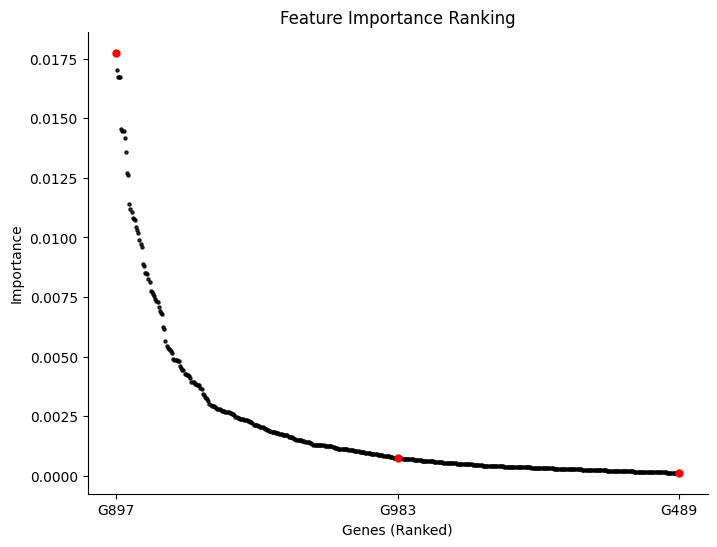

In [5]:
import matplotlib.pyplot as plt


# 设定绘制范围（例如前 500 个基因，避免X轴过长）
plot_top_n = 500
df_plot = featureimp_df.head(plot_top_n).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(8, 6))

# 1. 绘制主要曲线（用排名作为 X 轴）
ax.scatter(df_plot.index, df_plot["importance"], s=5, color="black", alpha=0.8)

# 2. 设定需要高亮/标记的基因
# 自动选择前 5 个，或者您可以手动指定列表，如 gene_list = ["Ins1", "Gcg"]
# gene_list = df_plot["gene"].head(5).tolist()
gene_list = df_plot["gene"][[0,plot_top_n//2, plot_top_n-1]].tolist()
# gene_list = ["Pdx1"]

marker_indices = []
marker_labels = []

for gene in gene_list:
    # 查找基因在排序后列表中的位置
    match = df_plot[df_plot["gene"] == gene]
    if not match.empty:
        idx = match.index[0]
        imp = match["importance"].values[0]
        
        marker_indices.append(idx)
        marker_labels.append(gene)
        
        # 用红点高亮
        ax.scatter([idx], [imp], s=25, color="red", zorder=10)

# 3. 自定义 X 轴刻度：只显示特定基因
ax.set_xticks(marker_indices)
ax.set_xticklabels(marker_labels, rotation=0, fontsize=10)

ax.set_xlabel("Genes (Ranked)")
ax.set_ylabel("Importance")
ax.set_title("Feature Importance Ranking")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.savefig(f"{img_dir}/feature_importance_ranking.pdf")
plt.show()

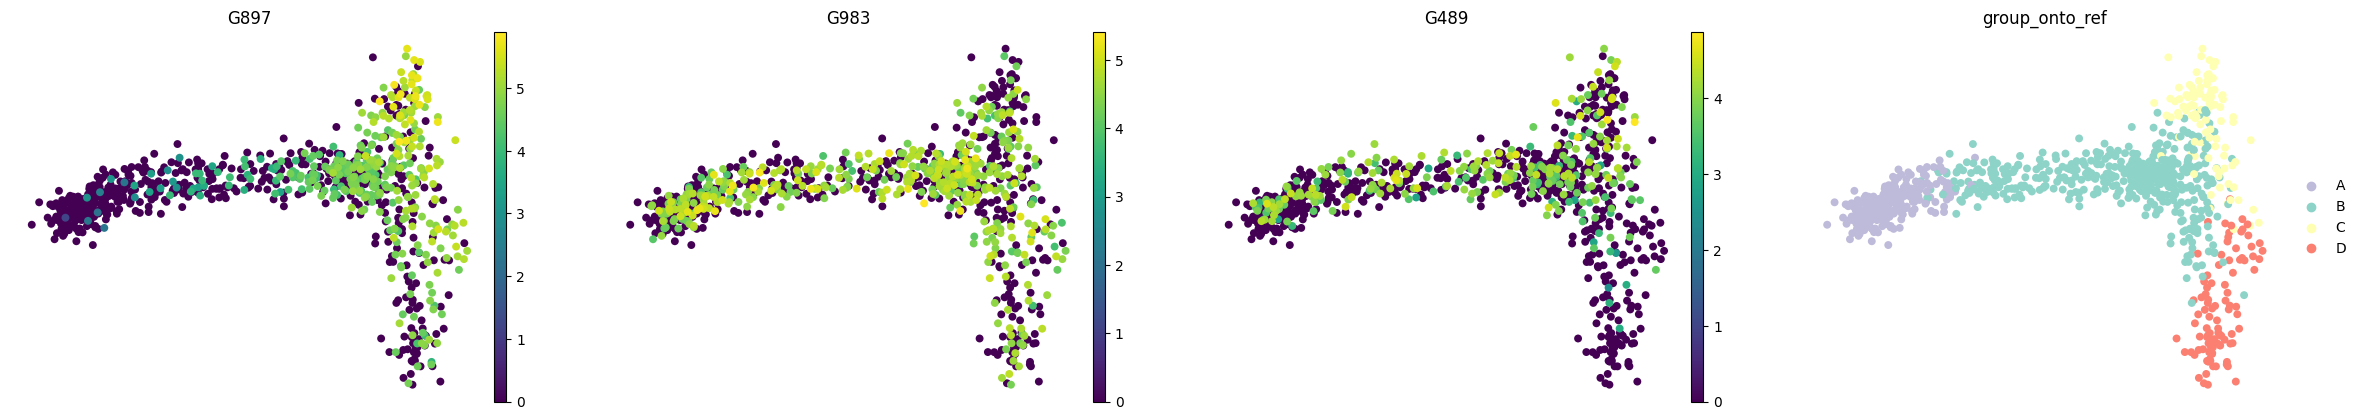

array([[<Axes: title={'center': 'ref(G897)'}, xlabel='_milestone_network_emb1', ylabel='_milestone_network_emb2'>,
        <Axes: title={'center': 'ref(G983)'}, xlabel='_milestone_network_emb1', ylabel='_milestone_network_emb2'>,
        <Axes: title={'center': 'ref(G489)'}, xlabel='_milestone_network_emb1', ylabel='_milestone_network_emb2'>,
        <Axes: title={'center': 'ref(group_onto_ref)'}, xlabel='_milestone_network_emb1', ylabel='_milestone_network_emb2'>]],
      dtype=object)

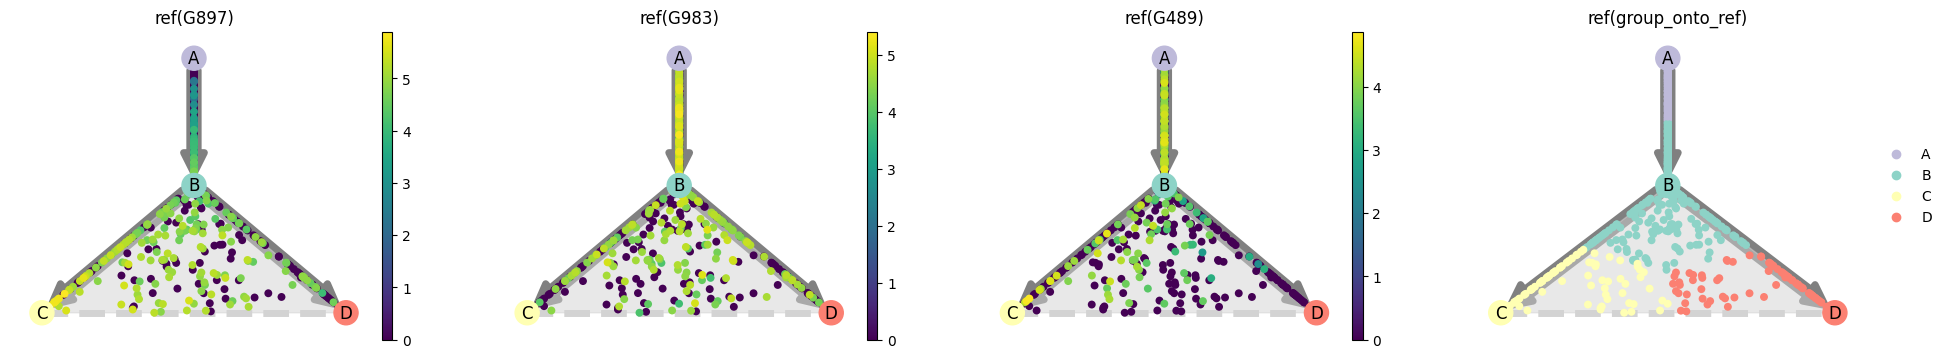

In [8]:

color_list = gene_list+[cluster_key]
sc.pl.embedding(
    fadata,
    basis=basis,
    color=color_list,
    save="sc.pl.embedding.pdf",
    frameon=False
)
cafe.plot.plot_graph(
    fadata,
    color=color_list,
    save=f"{img_dir}/plot_graph.pdf",
    figsize=(24, 4)
)

In [7]:
# gene = gene_list[0]
# fadata.prior_information["start_milestone"] = "M1"
# figs = cafe.plot.plot_stream(
#     fadata, 
#     model_name="ref",
#     color=gene,
#     mode="cell",
#     save=f"{img_dir}/stream_plot_{gene}.pdf",
#     show_legend=False, # need fixed
#     fig_size=(8,6)
# )